<a href="https://colab.research.google.com/github/ruyoliv/DataCom/blob/main/line_coding_schemes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📡 Line Coding Schemes Visualizer
This notebook visualizes 7 common line coding schemes:
**NRZ, Manchester, Differential Manchester, AMI, 2B1Q, 8B/6T, and MLT-3**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─── Input Data ───────────────────────────────────────────────────────────────
data_bits = [1, 0, 1, 1, 0, 0, 1, 0]   # 8-bit input sequence
data_bits = [1, 0, 1, 1, 1, 1, 1, 1]   # 8-bit input sequence
print(f"Input bits: {data_bits}")

Input bits: [1, 0, 1, 1, 1, 1, 1, 1]


In [ ]:
# ─── Helper: draw a staircase waveform ────────────────────────────────────────
def make_wave(levels, samples_per_bit=100):
    """Convert a list of voltage levels to a plottable (t, v) waveform."""
    t, v = [], []
    for i, lvl in enumerate(levels):
        t += [i * samples_per_bit, (i + 1) * samples_per_bit]
        v += [lvl, lvl]
    return np.array(t) / samples_per_bit, np.array(v)

n = len(data_bits)
t_bits = np.arange(n + 1)   # bit boundaries 0,1,...,n

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. NRZ (Non-Return-to-Zero)
#    1 → +V,  0 → 0V
# ══════════════════════════════════════════════════════════════════════════════
nrz = [1 if b else 0 for b in data_bits]
t_nrz, v_nrz = make_wave(nrz)

# ══════════════════════════════════════════════════════════════════════════════
# 2. Manchester
#    1 → low→high transition mid-bit
#    0 → high→low transition mid-bit
# ══════════════════════════════════════════════════════════════════════════════
man_levels = []
for b in data_bits:
    if b:
        man_levels += [-1, 1]   # rise
    else:
        man_levels += [1, -1]   # fall
t_man = np.linspace(0, n, 2 * n + 1)[:-1:1]   # half-bit steps
t_man2, v_man = [], []
for i, lvl in enumerate(man_levels):
    t_man2 += [i * 0.5, (i + 1) * 0.5]
    v_man  += [lvl, lvl]
t_man2, v_man = np.array(t_man2), np.array(v_man)

# ══════════════════════════════════════════════════════════════════════════════
# 3. Differential Manchester
#    Always transition mid-bit
#    0 → transition at START of bit; 1 → NO transition at start
# ══════════════════════════════════════════════════════════════════════════════
dm_levels = []
cur = 1   # start high
for b in data_bits:
    if b == 0:      # transition at start for 0
        cur = -cur
    first_half = cur
    cur = -cur      # always transition in middle
    second_half = cur
    dm_levels += [first_half, second_half]
t_dm, v_dm = [], []
for i, lvl in enumerate(dm_levels):
    t_dm += [i * 0.5, (i + 1) * 0.5]
    v_dm += [lvl, lvl]
t_dm, v_dm = np.array(t_dm), np.array(v_dm)

# ══════════════════════════════════════════════════════════════════════════════
# 4. AMI (Alternate Mark Inversion)
#    0 → 0V;  1 → alternate +1 / -1
# ══════════════════════════════════════════════════════════════════════════════
ami, polarity = [], 1
for b in data_bits:
    if b:
        ami.append(polarity)
        polarity *= -1
    else:
        ami.append(0)
t_ami, v_ami = make_wave(ami)

print("NRZ    :", nrz)
print("AMI    :", ami)

NRZ    : [1, 0, 1, 1, 1, 1, 1, 1]
AMI    : [1, 0, -1, 1, -1, 1, -1, 1]


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 5. 2B1Q  (2 Binary, 1 Quaternary)
#    Pairs of bits → one quaternary symbol
#    00→-3  01→-1  11→+1  10→+3
# ══════════════════════════════════════════════════════════════════════════════
map_2b1q = {(0,0): -3, (0,1): -1, (1,1): 1, (1,0): 3}
bits_2b1q = data_bits if len(data_bits) % 2 == 0 else data_bits + [0]
quats = [map_2b1q[(bits_2b1q[i], bits_2b1q[i+1])] for i in range(0, len(bits_2b1q), 2)]
t_2b1q = np.arange(len(quats) + 1)
t_2b1q_w, v_2b1q = [], []
for i, q in enumerate(quats):
    t_2b1q_w += [i, i+1]
    v_2b1q   += [q, q]
t_2b1q_w, v_2b1q = np.array(t_2b1q_w), np.array(v_2b1q)
# scale x to bit periods for consistent comparison
t_2b1q_w = t_2b1q_w * 2

print("2B1Q   :", quats)

2B1Q   : [3, 1, 1, 1]


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 6. 8B/6T  (8 Binary, 6 Ternary)
#    Encodes 8 bits into 6 ternary symbols {-1, 0, +1}
#    We simulate a simplified lookup for demonstration
#    (full 8B/6T has 256 table entries)
# ══════════════════════════════════════════════════════════════════════════════
import random
random.seed(42)

def byte_to_8b6t(byte_val):
    """Simplified 8B/6T: represent byte as 6 balanced ternary symbols."""
    # Convert to base-3 in 6 digits (0,1,2) then map 0→0, 1→+1, 2→-1
    digits = []
    v = byte_val
    for _ in range(6):
        digits.append(v % 3)
        v //= 3
    digits.reverse()
    return [0 if d == 0 else (1 if d == 1 else -1) for d in digits]

# Use first 8 bits as one byte
byte_val = int(''.join(map(str, data_bits)), 2)
t6 = byte_to_8b6t(byte_val)

t_8b6t_w, v_8b6t = [], []
# Each ternary symbol shown across proportional time
sym_w = n / 6   # 6 symbols span 8 bit-periods
for i, s in enumerate(t6):
    t_8b6t_w += [i * sym_w, (i+1) * sym_w]
    v_8b6t   += [s, s]
t_8b6t_w, v_8b6t = np.array(t_8b6t_w), np.array(v_8b6t)

print(f"8B/6T  : byte={byte_val} → {t6}")

8B/6T  : byte=191 → [0, -1, 1, 0, 0, -1]


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 7. MLT-3  (Multi-Level Transmit – 3 levels)
#    Cycle sequence: 0 → +1 → 0 → -1 → 0 → ...
#    0 → no change;  1 → advance to next state in cycle
# ══════════════════════════════════════════════════════════════════════════════
cycle = [0, 1, 0, -1]
idx, mlt3 = 0, []
for b in data_bits:
    if b:
        idx = (idx + 1) % 4
    mlt3.append(cycle[idx])
t_mlt3, v_mlt3 = make_wave(mlt3)

print("MLT-3  :", mlt3)

MLT-3  : [1, 1, 0, -1, 0, 1, 0, -1]


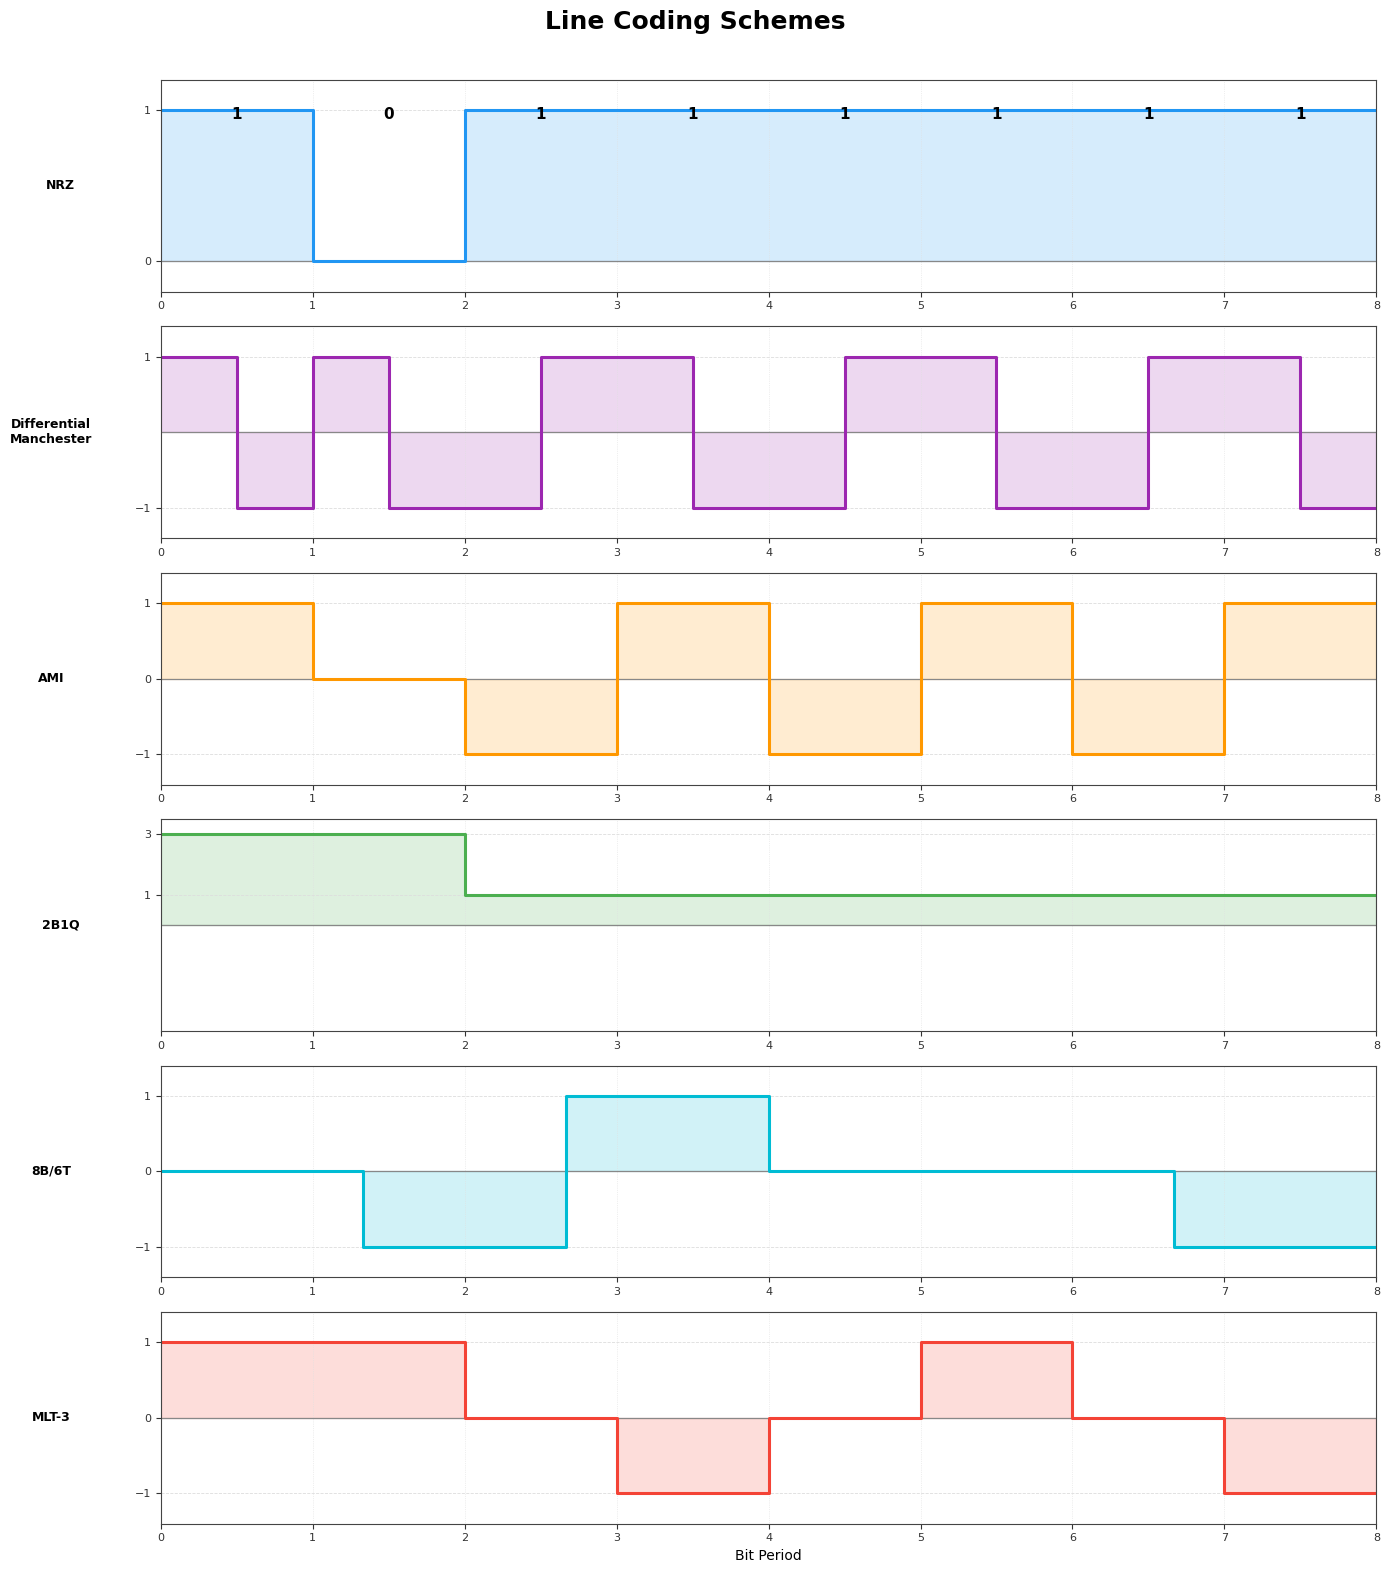


✅ Plot saved as line_coding.png


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT ALL SCHEMES
# ══════════════════════════════════════════════════════════════════════════════
schemes = [
    ("NRZ",                  t_nrz,    v_nrz,    [-0.2, 1.2],  '#2196F3'),
    #("Manchester",           t_man2,   v_man,    [-1.4, 1.4],  '#E91E63'),
    ("Differential\nManchester", t_dm, v_dm,    [-1.4, 1.4],  '#9C27B0'),
    ("AMI",                  t_ami,    v_ami,    [-1.4, 1.4],  '#FF9800'),
    ("2B1Q",                 t_2b1q_w, v_2b1q,  [-3.5, 3.5],  '#4CAF50'),
    ("8B/6T",                t_8b6t_w, v_8b6t,  [-1.4, 1.4],  '#00BCD4'),
    ("MLT-3",                t_mlt3,   v_mlt3,  [-1.4, 1.4],  '#F44336'),
]

fig, axes = plt.subplots(len(schemes), 1, figsize=(14, 16), facecolor='white')
fig.suptitle('Line Coding Schemes', fontsize=18,
             fontweight='bold', y=0.98, color='black')

for ax, (name, t, v, ylim, color) in zip(axes, schemes):
    ax.set_facecolor('white')

    # spines
    for spine in ax.spines.values():
        spine.set_color('#444444')

    ax.tick_params(colors='#333333', labelsize=8)

    # grid
    ax.grid(axis='y', color='#dddddd', linewidth=0.6, linestyle='--')
    for xb in range(n + 1):
        ax.axvline(xb, color='#e0e0e0', linewidth=0.5, linestyle=':')

    # zero line
    ax.axhline(0, color='#888888', linewidth=0.9)

    # waveform
    ax.step(t, v, where='post', color=color, linewidth=2.2)
    ax.fill_between(t, 0, v, step='post', alpha=0.18, color=color)

    ax.set_xlim(0, n)
    ax.set_ylim(ylim)
    ax.set_ylabel(name, fontsize=9, fontweight='bold',
                  rotation=0, labelpad=60, va='center', color='black')

    ax.set_yticks(sorted(set(v.tolist())))

    # bit labels on top of first subplot
    if name == "NRZ":
        for i, b in enumerate(data_bits):
            ax.text(i + 0.5, ylim[1] * 0.85, str(b),
                    ha='center', va='top',
                    color='black', fontsize=11, fontweight='bold')

axes[-1].set_xlabel('Bit Period', fontsize=10, color='black')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('line_coding.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

print("\n✅ Plot saved as line_coding.png")

## Scheme Summary

| Scheme | Levels | Notes |
|--------|--------|-------|
| **NRZ** | 2 | Simple; DC component; no self-sync |
| **Manchester** | 2 | Always mid-bit transition; self-clocking; 2× bandwidth |
| **Diff. Manchester** | 2 | Transition at start for 0; immune to polarity reversal |
| **AMI** | 3 | Alternates ±1 for 1s; no DC; can lose sync on long 0-runs |
| **2B1Q** | 4 | 2 bits per baud; used in ISDN BRI |
| **8B/6T** | 3 | 8 bits → 6 ternary; used in 100BASE-T4 |
| **MLT-3** | 3 | Cycles 0→+1→0→-1; used in 100BASE-TX (FDDI) |